In [1]:
import torch
print("PyTorch version " + torch.__version__)
# Detectar y inicializar GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Running on CPU")

# Importaciones de PyTorch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Importación de la clase WaveletDenoising
!pip install PyWavelets
import pywt

# Importación de librerías necesarias
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import signal
import h5py
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Configuraciones globales para visualización
plt.style.use('seaborn-v0_8-whitegrid')

PyTorch version 2.8.0+cu126
Running on GPU: Tesla T4


In [2]:
# Para montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Balanceo de clases aplicado:
- Muestras No-leak: 240
- Muestras Leak (total): 240
- Muestras por tipo de fuga: 60
Data Directory: /content/drive/MyDrive/Dataset/Branched
Sample Rate: 25600 Hz
Classification Mode: binary
Number of signals (training, testing): (384, 96)
Number of labels (training, testing): (384, 96)
Number of samples per signal: 25600


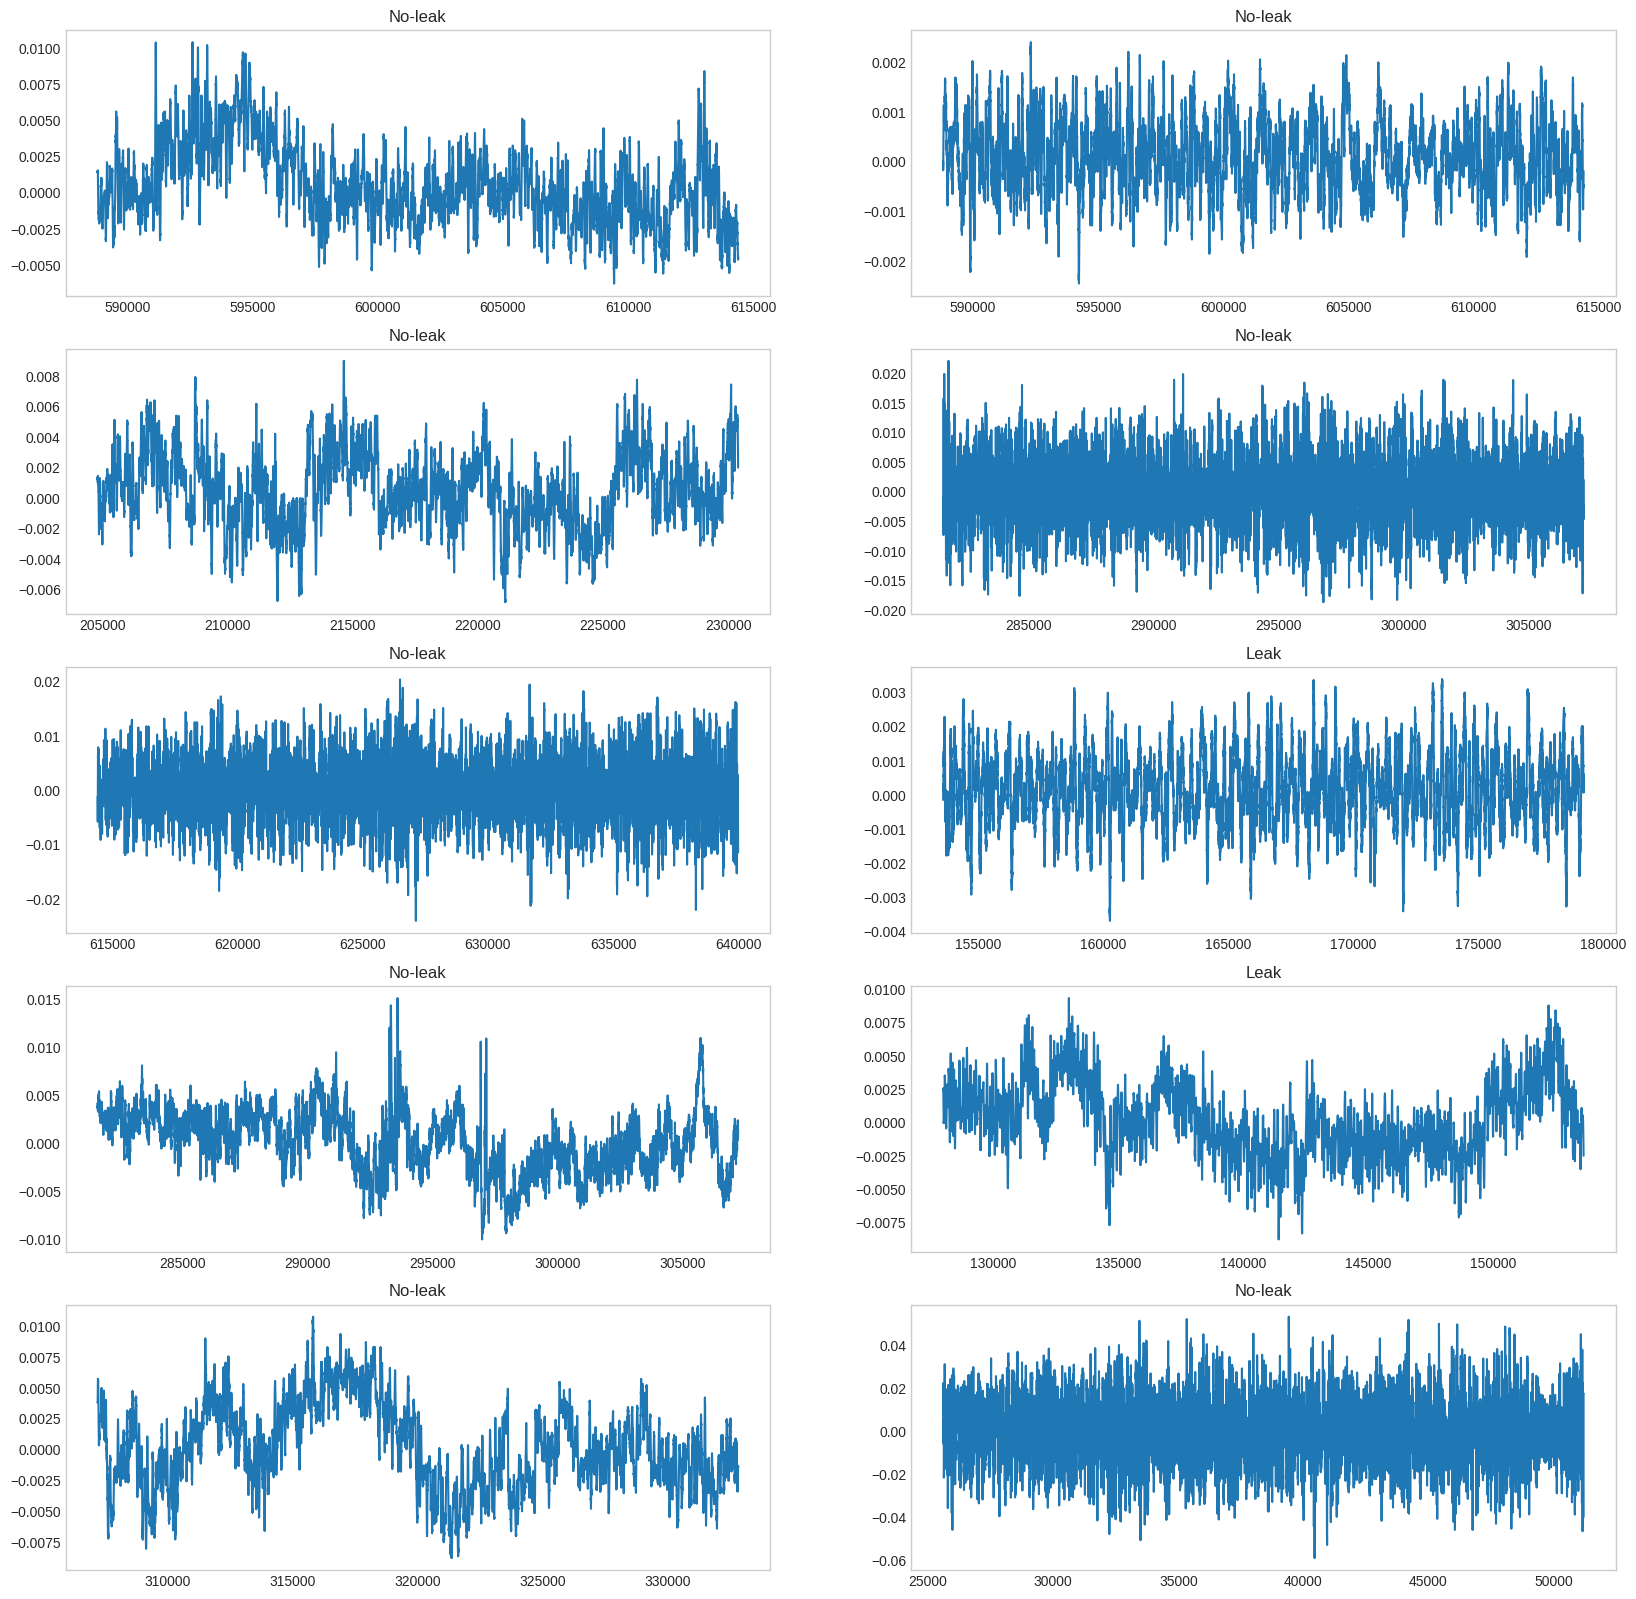

In [3]:
# Definir la ruta de los datos en Google Drive
data_dir = '/content/drive/MyDrive/Dataset/Branched'
original_sr = 25600 # Frecuencia de muestreo original en Hz
signal_sr = 25600 # Frecuencia de muestreo deseada en Hz
downsample_factor = original_sr // signal_sr

# Modo de clasificación: 'five_classes' o 'binary'
classification_mode = 'binary' # Cambiar según necesidad

# Diccionario de etiquetas según el modo de clasificación
if classification_mode == 'five_classes':
    label_codes_dict = {
        'Circumferential Crack': 0,
        'Gasket Leak': 1,
        'Longitudinal Crack': 2,
        'No-leak': 3,
        'Orifice Leak': 4
    }
else: # binary
    label_codes_dict = {'Leak': 0, 'No-leak': 1}

# Función para eliminar archivos .DS_Store si existen
def remove_DS_store_file(path):
    for ds_name in ['.DS_Store', '.DS_store']:
        ds_store_file_location = os.path.join(path, ds_name)
        if os.path.isfile(ds_store_file_location):
            os.remove(ds_store_file_location)

def load_accelerometer_data(data_dir, sample_rate, downsample_factor, label_codes, mode='five_classes', fraction_to_include=1):
    remove_DS_store_file(data_dir)
    signals = []
    labels = []

    # Para submuestreo en modo binario
    if mode == 'binary':
        # Diccionario para rastrear señales por tipo de fuga
        leak_type_signals = {
            'Circumferential Crack': [],
            'Gasket Leak': [],
            'Longitudinal Crack': [],
            'Orifice Leak': []
        }
        no_leak_signals = []
        sample_labels = [] # Para almacenar etiquetas originales (para estratificación)

    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            print(f"Omitiendo {label_dir} porque no es un directorio")
            continue

        remove_DS_store_file(label_dir)

        for file in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file)
            if not os.path.isfile(file_path):
                continue

            accelerometer_signal_df = pd.read_csv(file_path, index_col=False)
            accelerometer_signal_df = accelerometer_signal_df.iloc[::downsample_factor, :].reset_index(drop=True)
            accelerometer_signal = accelerometer_signal_df['Value'][0:(sample_rate * 30)]

            sample_indexes = np.linspace(0, len(accelerometer_signal) - sample_rate, len(accelerometer_signal) // sample_rate)
            signal_frames_number = fraction_to_include * len(sample_indexes)
            signal_frames_counter = 0

            for signal_frame in sample_indexes:
                accelerometer_signal_frame = accelerometer_signal[int(signal_frame):int(signal_frame + sample_rate)]
                signal_frames_counter += 1

                if signal_frames_counter > signal_frames_number:
                    break

                if len(accelerometer_signal_frame) != sample_rate:
                    continue

                if mode == 'five_classes':
                    signals.append(accelerometer_signal_frame)
                    labels.append(label_codes[label])
                else: # binary
                    # En vez de añadir directamente, almacenamos por tipo de fuga
                    if label == 'No-leak':
                        no_leak_signals.append(accelerometer_signal_frame)
                        sample_labels.append('No-leak')
                    else:
                        # Almacenar en el diccionario correspondiente
                        leak_type_signals[label].append(accelerometer_signal_frame)
                        sample_labels.append(label)

    # Para modo binario, realizar submuestreo equilibrado
    if mode == 'binary':
        # Número total de muestras No-leak
        total_no_leak = len(no_leak_signals)

        # Calcular cuántas muestras tomar de cada tipo de fuga para balancear con No-leak
        samples_per_leak_type = total_no_leak // 4 # Dividir entre los 4 tipos de fuga

        # Si hay muy pocas muestras de algún tipo, ajustar todas para mantener la proporcionalidad
        min_available = min([len(leak_signals) for leak_signals in leak_type_signals.values()])
        if min_available < samples_per_leak_type:
            samples_per_leak_type = min_available

        # Limitar cada tipo de fuga a la cantidad calculada para balanceo
        balanced_leak_signals = []
        balanced_labels = []
        balanced_stratify = []

        # Añadir todas las muestras No-leak
        for signal in no_leak_signals:
            balanced_leak_signals.append(signal)
            balanced_labels.append(1) # No-leak
            balanced_stratify.append('No-leak')

        # Añadir cantidades equilibradas de cada tipo de fuga
        for leak_type, leak_signals in leak_type_signals.items():
            # Tomar exactamente samples_per_leak_type muestras de cada tipo de fuga
            for signal in leak_signals[:samples_per_leak_type]:
                balanced_leak_signals.append(signal)
                balanced_labels.append(0) # Leak
                balanced_stratify.append(leak_type) # Guardar tipo original para estratificación

        print(f"Balanceo de clases aplicado:")
        print(f"- Muestras No-leak: {total_no_leak}")
        print(f"- Muestras Leak (total): {samples_per_leak_type * 4}")
        print(f"- Muestras por tipo de fuga: {samples_per_leak_type}")

        return balanced_leak_signals, balanced_labels, balanced_stratify

    return signals, labels, None # None para modo five_classes

# Cargar los datos con submuestreo equilibrado
signals_lst, labels_lst, stratify_labels = load_accelerometer_data(
    data_dir,
    signal_sr,
    downsample_factor,
    label_codes_dict,
    mode=classification_mode,
    fraction_to_include=1
)

# Dividir los datos en conjuntos de entrenamiento y prueba con estratificación
signals_dict = {'training': [], 'testing': []}
labels_dict = {'training': [], 'testing': []}

if stratify_labels:
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'], stratify_train, stratify_test = train_test_split(
        signals_lst,
        labels_lst,
        stratify_labels,
        test_size=0.2,
        random_state=53,
        stratify=stratify_labels
    )
else:
    # Para modo five_classes, usar las etiquetas para estratificar
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'] = train_test_split(
        signals_lst,
        labels_lst,
        test_size=0.2,
        random_state=53,
        stratify=labels_lst # Estratificar por las etiquetas directamente
    )

# Imprimir información sobre el dataset
print(f'Data Directory: {data_dir}')
print(f'Sample Rate: {signal_sr} Hz')
print(f'Classification Mode: {classification_mode}')
print(f'Number of signals (training, testing): ({len(signals_dict["training"])}, {len(signals_dict["testing"])})')
print(f'Number of labels (training, testing): ({len(labels_dict["training"])}, {len(labels_dict["testing"])})')
print(f'Number of samples per signal: {len(signals_dict["training"][0])}')


# Visualizar algunas señales
plt.figure(figsize=(20, 20))
rows, cols = 5, 2
n = rows * cols
random_index = []

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    random_index.append(np.random.randint(0, len(signals_dict['training'])))
    plt.plot(signals_dict['training'][random_index[i]])

    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    plt.title(label_name)
    plt.grid()
plt.show()

In [4]:
# Modificación de la clase WaveletDenoising para especificar wavelet y nivel directamente
import tqdm
class WaveletDenoising:
    """Clase para denoising con wavelets con wavelet y nivel específicos."""

    def __init__(self, normalize=True, wavelet='db4', level=3, thr_mode='soft', method="universal"):
        """
        Inicializa el denoiser con parámetros específicos.

        Args:
            normalize: Si es True, normaliza la señal antes del denoising.
            wavelet: Wavelet a utilizar.
            level: Nivel de descomposición wavelet.
            thr_mode: Modo de umbralización ('soft' o 'hard').
            method: Método de umbralización ("universal" o "level_dependent").
        """
        self.normalize = normalize
        self.wavelet = wavelet
        self.level = level
        self.thr_mode = thr_mode
        self.method = method

    def fit(self, data):
        """Aplica el denoising a los datos de entrada."""
        # Convertir a array numpy
        data = np.asarray(data)

        # Normalizar si es necesario
        if self.normalize:
            data = (data - np.mean(data)) / (np.std(data) if np.std(data) != 0 else 1.0)

        # Descomponer con wavelet
        coeffs = pywt.wavedec(data, self.wavelet, level=self.level)

        # Umbral
        if self.method == "universal":
            sigma = self._estimate_sigma(coeffs[-1])
            threshold = sigma * np.sqrt(2 * np.log(len(data)))
        else:
            threshold = self._estimate_level_dependent_threshold(coeffs)

        # Aplicar umbral
        new_coeffs = []
        new_coeffs.append(coeffs[0]) # Aproximación
        for i in range(1, len(coeffs)):
            if self.thr_mode == 'soft':
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
            else:
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='hard'))

        # Reconstruir
        return pywt.waverec(new_coeffs, self.wavelet)

    def _estimate_sigma(self, detail_coeffs):
        """Estima la desviación estándar del ruido."""
        return np.median(np.abs(detail_coeffs)) / 0.6745

    def _estimate_level_dependent_threshold(self, coeffs):
        """Estima umbrales dependientes del nivel."""
        return np.std(coeffs[-1]) * 3.0

def apply_wavelet_denoising(signals_dict, wavelet, level):
    """
    Aplica denoising wavelet con una wavelet y nivel específicos.

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        wavelet: Nombre de la wavelet a utilizar
        level: Nivel de descomposición

    Returns:
        wavelet_denoised_signals: Diccionario con señales procesadas
    """
    # Crear objeto WaveletDenoising con los parámetros especificados
    wd = WaveletDenoising(
        normalize=True,
        wavelet=wavelet,
        level=level,
        thr_mode='soft',
        method="universal"
    )

    # Crear diccionario para señales procesadas
    wavelet_denoised_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal_element in tqdm.tqdm(signals_subset, desc=f"Aplicando {wavelet} nivel {level} a {key}"):
            # Denoising de la señal
            try:
                denoised_signal = wd.fit(signal_element)
                wavelet_denoised_signals[key].append(denoised_signal)
            except Exception as e:
                print(f"Error al procesar señal con {wavelet} nivel {level}: {str(e)}")
                # En caso de error, usar la señal original
                wavelet_denoised_signals[key].append(signal_element)

    return wavelet_denoised_signals

wavelet_denoised_signals_dict=apply_wavelet_denoising(signals_dict, "db38", 4)

# Función para normalizar señales
def normalize_signals(signals_dict):
    """
    Normaliza cada señal del diccionario a un rango de 0 a 1.

    Args:
        signals_dict: Diccionario con señales a normalizar.

    Returns:
        normalized_signals: Diccionario con señales normalizadas.
    """
    normalized_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal in tqdm.tqdm(signals_subset, desc=f"Normalizando {key} signals"):
            min_val = np.min(signal)
            max_val = np.max(signal)

            if max_val > min_val:
                normalized_signal = (signal - min_val) / (max_val - min_val)
            else:
                normalized_signal = np.ones_like(signal) * 0.5

            normalized_signals[key].append(normalized_signal)

    return normalized_signals

wavelet_denoised_signals_dict=normalize_signals(wavelet_denoised_signals_dict)

Normalizando testing signals: 100%|██████████| 96/96 [00:00<00:00, 7032.38it/s]


Generating spectrograms for testing: 100%|██████████| 96/96 [00:00<00:00, 548.74it/s]


Number of spectrograms (training, testing): (384, 96)
Spectrogram shape: (257, 101)


<Figure size 2000x2200 with 0 Axes>

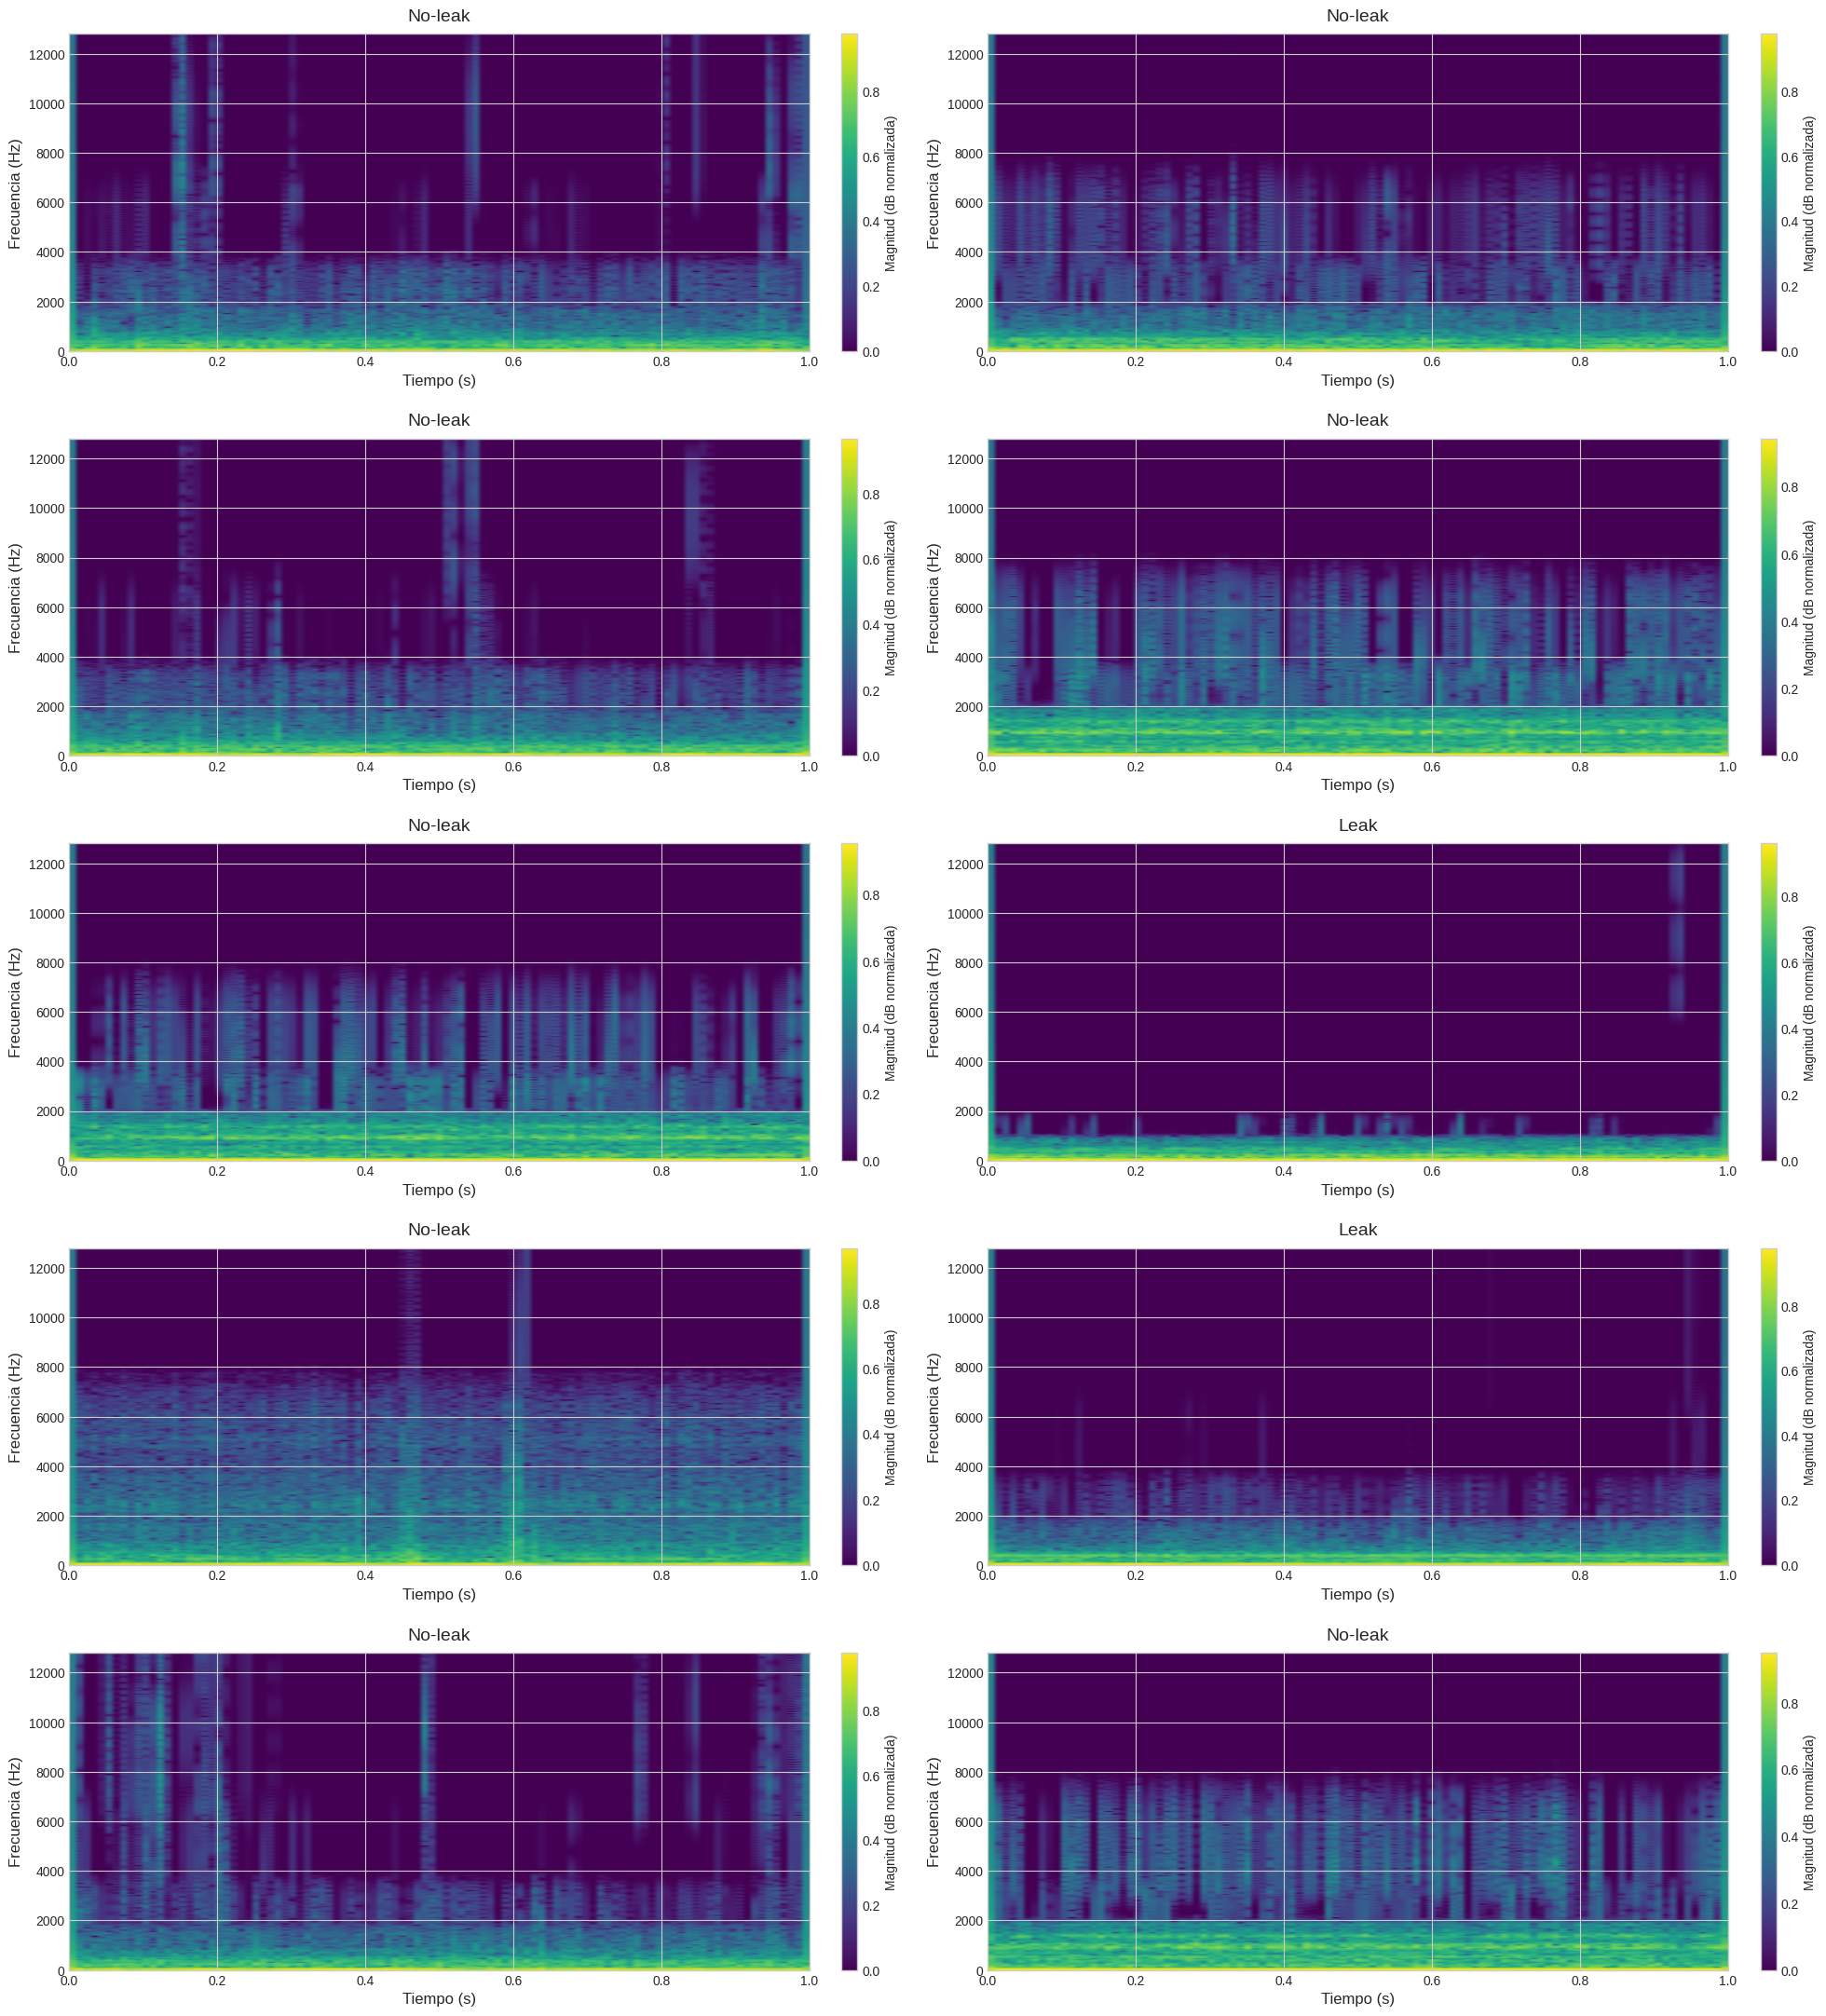

In [5]:
def generate_log_spectrograms(signals_dict, labels_dict, fs=25600):
    """
    Genera espectrogramas logarítmicos usando STFT

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        labels_dict: Diccionario con etiquetas
        fs: Frecuencia de muestreo en Hz

    Returns:
        spectrograms_dict: Diccionario con espectrogramas
        labels_dict: Diccionario con etiquetas
    """
    # Parámetros para STFT adaptados a nuestra frecuencia de muestreo (25.6kHz vs 8kHz del paper)
    # Frame length: 20ms x 25.6kHz = 512 muestras
    # Frame shift: 10ms x 25.6kHz = 256 muestras
    frame_length = int(0.02 * fs) # 20 ms
    frame_shift = int(0.01 * fs) # 10 ms
    nfft = 512 # Tamaño de FFT como se especificó

    # Crear diccionario para almacenar espectrogramas
    spectrograms_dict = {'training': [], 'testing': []}

    # Verificar si es necesario eliminar frames con ruido de alta energía
    apply_denoising = False

    # Umbral para identificar frames con ruido (ajustar según sea necesario)
    mean_threshold = 0.7
    std_threshold = 0.5

    for key, signals_subset in signals_dict.items():
        for i, signal in enumerate(tqdm.tqdm(signals_subset, desc=f"Generating spectrograms for {key}")):
            # Aplicar STFT
            f, t, Zxx = scipy.signal.stft(
                signal,
                fs=fs,
                window='hann',
                nperseg=frame_length,
                noverlap=frame_length-frame_shift,
                nfft=nfft
            )

            # Calcular espectrograma de potencia (magnitud al cuadrado)
            power_spectrogram = np.abs(Zxx)**2

            if apply_denoising:
                # Identificar frames con ruido de alta energía
                frame_means = np.mean(power_spectrogram, axis=0)
                frame_stds = np.std(power_spectrogram, axis=0)

                # Normalizar para obtener valores relativos
                norm_means = frame_means / np.max(frame_means)
                norm_stds = frame_stds / np.max(frame_stds)

                # Identificar frames ruidosos que superan los umbrales
                noisy_frames = (norm_means > mean_threshold) | (norm_stds > std_threshold)

                # Procesar frames ruidosos
                for j, is_noisy in enumerate(noisy_frames):
                    if is_noisy:
                        # Obtener el espectro del frame actual
                        frame_spectrum = power_spectrogram[:, j]

                        # Reemplazar valores de baja frecuencia (< 300Hz) que podrían contener ruido de baja frecuencia
                        low_freq_bins = int(300 / (fs/2) * (nfft//2))
                        frame_spectrum[:low_freq_bins] = np.mean(frame_spectrum[:low_freq_bins]) * 0.1

                        # Encontrar los picos locales (1-2 picos)
                        # Usamos una ventana de 10 bins para encontrar máximos locales
                        from scipy.signal import find_peaks
                        peaks, _ = find_peaks(frame_spectrum, distance=10)

                        if len(peaks) > 0:
                            # Crear una nueva versión del espectro con solo los picos principales
                            new_spectrum = np.zeros_like(frame_spectrum)

                            # Tomar los 2 picos más grandes si hay suficientes
                            num_peaks_to_keep = min(2, len(peaks))
                            peak_indices = peaks[np.argsort(frame_spectrum[peaks])[-num_peaks_to_keep:]]

                            # Mantener valor solo en los picos y sus alrededores
                            for peak_idx in peak_indices:
                                window_size = 5 # Bins a mantener alrededor del pico
                                start_idx = max(0, peak_idx - window_size)
                                end_idx = min(len(frame_spectrum), peak_idx + window_size + 1)
                                new_spectrum[start_idx:end_idx] = frame_spectrum[start_idx:end_idx]

                            # Reemplazar el frame original
                            power_spectrogram[:, j] = new_spectrum

            # Convertir a escala logarítmica (dB), agregando un pequeño valor para evitar log(0)
            eps = 1e-10
            log_spectrogram = 10 * np.log10(power_spectrogram + eps)

            # Normalizar a un rango adecuado
            log_spectrogram = np.clip(log_spectrogram, -100, 0) # Limitar valores mínimos
            log_spectrogram = (log_spectrogram + 100) / 100 # Normalizar a [0, 1]

            # Transponer para tener tiempo en el eje horizontal y frecuencia en el vertical
            # También invertir el eje de frecuencia para que las frecuencias bajas estén abajo
            #log_spectrogram = log_spectrogram.T

            # Almacenar en el diccionario
            spectrograms_dict[key].append(log_spectrogram)

    return spectrograms_dict, labels_dict

# Generar espectrogramas logarítmicos
spectrograms_dict, labels_dict = generate_log_spectrograms(
    wavelet_denoised_signals_dict,
    labels_dict,
    fs=signal_sr
)

# Imprimir información sobre los espectrogramas
print(f'Number of spectrograms (training, testing): ({len(spectrograms_dict["training"])}, {len(spectrograms_dict["testing"])})')
print(f'Spectrogram shape: {spectrograms_dict["training"][0].shape}')

# Visualizar algunos espectrogramas
plt.figure(figsize=(20, 22)) # Aumentado el alto para más separación vertical
rows = 5
cols = 2
n = rows * cols

# Crear figura con más espacio entre subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 22))
fig.subplots_adjust(hspace=0.5, wspace=0.3) # Aumentar separación horizontal y vertical

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

for i in range(n):
    # Usar el eje específico en lugar de plt.subplot
    ax = axes[i]

    # Usar viridis como paleta de color
    im = ax.imshow(spectrograms_dict['training'][random_index[i]],
                aspect='auto',
                origin='lower',
                cmap='viridis', # Paleta de color verde-azul
                extent=[0, 1, 0, signal_sr/2])

    # Obtener el nombre de la etiqueta según el modo de clasificación
    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    # Añadir barra de color al lado de cada gráfico
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Magnitud (dB normalizada)')

    # Configurar títulos y etiquetas
    ax.set_title(label_name, fontsize=14, pad=10) # Añadir más padding al título
    ax.set_xlabel('Tiempo (s)', fontsize=12)
    ax.set_ylabel('Frecuencia (Hz)', fontsize=12)

plt.tight_layout(pad=2.0) # Asegurar que no haya solapamiento
plt.show()

In [6]:
import torch.nn.functional as F

def prepare_data_for_model(spectrograms_dict, labels_dict, classification_mode):
    """
    Prepara los datos para el modelo ViT.

    Args:
        spectrograms_dict: Diccionario con espectrogramas
        labels_dict: Diccionario con etiquetas
        classification_mode: Modo de clasificación ('five_classes' o 'binary')

    Returns:
        x_train, y_train, x_test, y_test, num_classes: Datos preparados para entrenamiento
    """
    # Convertir a tensores de PyTorch
    x_train = torch.tensor(np.array(spectrograms_dict['training']), dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(np.array(labels_dict['training']), dtype=torch.long)
    x_test = torch.tensor(np.array(spectrograms_dict['testing']), dtype=torch.float32).unsqueeze(1)
    y_test = torch.tensor(np.array(labels_dict['testing']), dtype=torch.long)

    # Redimensionar los tensores a 3 canales para un ViT pre-entrenado
    # El ViT espera una entrada de 3 canales (RGB), por lo que debemos replicar el canal
    x_train_3ch = x_train.repeat(1, 3, 1, 1)
    x_test_3ch = x_test.repeat(1, 3, 1, 1)

    # Determinar número de clases según el modo
    if classification_mode == 'five_classes':
        num_classes = 5
    else: # binary
        num_classes = 2

    # One-hot encoding de las etiquetas de entrenamiento y prueba
    y_train_onehot = F.one_hot(y_train, num_classes=num_classes).float()
    y_test_onehot = F.one_hot(y_test, num_classes=num_classes).float()

    return x_train_3ch, y_train, y_train_onehot, x_test_3ch, y_test, y_test_onehot, num_classes

# Preparar los datos para el modelo
x_train, y_train, y_train_onehot, x_test, y_test, y_test_onehot, num_classes = prepare_data_for_model(
    spectrograms_dict,
    labels_dict,
    classification_mode
)

# NUEVO: Dividir los datos de entrenamiento en conjuntos de entrenamiento y validación
from sklearn.model_selection import train_test_split
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2, # 20% para validación
    random_state=42,
    stratify=y_train # Asegura una distribución equitativa de clases
)

# Convertir etiquetas a formato adecuado para el entrenamiento
if classification_mode == 'five_classes':
    y_val_onehot = F.one_hot(y_val, num_classes=num_classes).float()
    y_train_final_onehot = F.one_hot(y_train_final, num_classes=num_classes).float()
else: # binary
    y_val_onehot = y_val.float().reshape(-1, 1)
    y_train_final_onehot = y_train_final.float().reshape(-1, 1)

# Imprimir información sobre los datos preparados
print(f'x_train shape (total): {x_train.shape}')
print(f'x_train_final shape (después de separar validación): {x_train_final.shape}')
print(f'x_val shape: {x_val.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'Number of classes: {num_classes}')

# Guardar en formato HDF5
def save_dataset_to_h5(x_train, y_train, y_train_onehot, x_val, y_val, x_test, y_test, y_test_onehot,
                        classification_mode, num_classes, label_codes_dict,
                        file_path=None):
    """
    Guarda el dataset en formato HDF5 incluyendo el conjunto de validación
    """
    if file_path is None:
        file_path = f'/content/drive/MyDrive/STFT modelo preentrenado/Branched/branched_db38_lv4_log_spectrogram_dataset_{classification_mode}.h5'

    print(f"Guardando dataset en {file_path}...")
    with h5py.File(file_path, 'w') as hf:
        # Convertir tensores a arrays de numpy antes de guardar
        x_train_np = x_train.cpu().numpy()
        y_train_np = y_train.cpu().numpy()
        y_train_onehot_np = y_train_onehot.cpu().numpy()
        x_val_np = x_val.cpu().numpy()
        y_val_np = y_val.cpu().numpy()
        x_test_np = x_test.cpu().numpy()
        y_test_np = y_test.cpu().numpy()
        y_test_onehot_np = y_test_onehot.cpu().numpy()

        # Crear grupos para training, validación y testing
        train_group = hf.create_group('train')
        val_group = hf.create_group('val')
        test_group = hf.create_group('test')

        # Guardar espectrogramas y etiquetas procesados
        train_group.create_dataset('spectrograms', data=x_train_np)
        train_group.create_dataset('labels', data=y_train_np)
        train_group.create_dataset('labels_onehot', data=y_train_onehot_np)

        # Guardar datos de validación
        val_group.create_dataset('spectrograms', data=x_val_np)
        val_group.create_dataset('labels', data=y_val_np)

        # Guardar datos de prueba
        test_group.create_dataset('spectrograms', data=x_test_np)
        test_group.create_dataset('labels', data=y_test_np)
        test_group.create_dataset('labels_onehot', data=y_test_onehot_np)

        # Guardar metadatos
        metadata = hf.create_group('metadata')
        metadata.create_dataset('num_classes', data=num_classes)
        metadata.create_dataset('shape', data=np.array(x_train_np.shape[1:]))
        metadata.attrs['classification_mode'] = classification_mode

        # Guardar diccionario de etiquetas
        import json
        if classification_mode == 'five_classes':
            label_codes_json = json.dumps({k: int(v) for k, v in label_codes_dict.items()})
        else: # binary
            label_codes_json = json.dumps({k: int(v) for k, v in {'Leak': 0, 'No-leak': 1}.items()})
        metadata.attrs['label_codes_dict'] = label_codes_json

    print(f"Dataset procesado y guardado en {file_path}")
    print(f"Datos de entrenamiento: {len(x_train_final)} muestras")
    print(f"Datos de validación: {len(x_val)} muestras")
    print(f"Datos de prueba: {len(x_test)} muestras")

    # Verificar la existencia del archivo guardado
    if os.path.exists(file_path):
        print(f"Archivo guardado correctamente. Tamaño: {os.path.getsize(file_path) / (1024*1024):.2f} MB")
    else:
        print("Error: No se pudo guardar el archivo")

# Guardar el dataset incluyendo el conjunto de validación
save_dataset_to_h5(
    x_train_final, y_train_final, y_train_onehot,
    x_val, y_val,
    x_test, y_test, y_test_onehot,
    classification_mode, num_classes, label_codes_dict
)

x_train shape (total): torch.Size([384, 3, 257, 101])
x_train_final shape (después de separar validación): torch.Size([307, 3, 257, 101])
x_val shape: torch.Size([77, 3, 257, 101])
x_test shape: torch.Size([96, 3, 257, 101])
Number of classes: 2
Guardando dataset en /content/drive/MyDrive/STFT modelo preentrenado/Branched/branched_db38_lv4_log_spectrogram_dataset_binary.h5...
Dataset procesado y guardado en /content/drive/MyDrive/STFT modelo preentrenado/Branched/branched_db38_lv4_log_spectrogram_dataset_binary.h5
Datos de entrenamiento: 307 muestras
Datos de validación: 77 muestras
Datos de prueba: 96 muestras
Archivo guardado correctamente. Tamaño: 142.61 MB


In [7]:
# Cargar dataset H5 para entrenar modelos directamente

# Importaciones necesarias
import os
import numpy as np
import h5py
import json
import torch
from sklearn.model_selection import train_test_split

def cargar_dataset_h5(ruta_archivo=None):
    """
    Carga el dataset previamente guardado en formato H5.

    Args:
        ruta_archivo: Ruta al archivo H5. Si es None, usa la ruta por defecto.

    Returns:
        Todos los datos necesarios para el entrenamiento.
    """
    if ruta_archivo is None:
        # Usamos la ruta de Google Drive que guardaste exitosamente
        ruta_archivo = '/content/drive/MyDrive/STFT modelo preentrenado/Branched/branched_db38_lv4_log_spectrogram_dataset_binary.h5'

    print(f"Cargando dataset desde: {ruta_archivo}")

    with h5py.File(ruta_archivo, 'r') as hf:
        # Cargar datos de entrenamiento
        x_train_final = np.array(hf['train']['spectrograms'])
        y_train_final = np.array(hf['train']['labels'])
        y_train_onehot = np.array(hf['train']['labels_onehot'])

        # Cargar datos de validación
        x_val = np.array(hf['val']['spectrograms'])
        y_val = np.array(hf['val']['labels'])

        # Cargar datos de test
        x_test = np.array(hf['test']['spectrograms'])
        y_test = np.array(hf['test']['labels'])
        y_test_onehot = np.array(hf['test']['labels_onehot'])

        # Cargar metadatos
        num_classes = np.array(hf['metadata']['num_classes'])[()]
        classification_mode = hf['metadata'].attrs['classification_mode']
        input_shape = tuple(np.array(hf['metadata']['shape']))

        # Cargar diccionario de etiquetas
        label_codes_json = hf['metadata'].attrs['label_codes_dict']
        label_codes_dict = json.loads(label_codes_json)

    # Para mantener la consistencia, convertimos los arrays de numpy a tensores de PyTorch
    x_train_final = torch.tensor(x_train_final, dtype=torch.float32)
    y_train_final = torch.tensor(y_train_final, dtype=torch.long)
    x_val = torch.tensor(x_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)
    x_test = torch.tensor(x_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # Concatenar para obtener el conjunto de entrenamiento total (incluyendo validación)
    x_train = torch.cat([x_train_final, x_val], dim=0)
    y_train = torch.cat([y_train_final, y_val], dim=0)

    # Mostrar información sobre los datos cargados
    print("\n=== Información del Dataset Cargado ===")
    print(f"Modo de clasificación: {classification_mode}")
    print(f"x_train shape (total): {x_train.shape}")
    print(f"x_train_final shape: {x_train_final.shape}")
    print(f"x_val shape: {x_val.shape}")
    print(f"x_test shape: {x_test.shape}")
    print(f"Número de clases: {num_classes}")

    return (x_train, y_train, x_train_final, y_train_final,
            x_val, y_val, x_test, y_test, num_classes,
            classification_mode, input_shape, label_codes_dict)

# Cargar todos los datos necesarios
(x_train, y_train, x_train_final, y_train_final,
 x_val, y_val, x_test, y_test, num_classes,
 classification_mode, input_shape, label_codes_dict) = cargar_dataset_h5()

print("\n¡Dataset cargado exitosamente! Listo para la aumentación de datos y el entrenamiento del modelo.")

Cargando dataset desde: /content/drive/MyDrive/STFT modelo preentrenado/Branched/branched_db38_lv4_log_spectrogram_dataset_binary.h5

=== Información del Dataset Cargado ===
Modo de clasificación: binary
x_train shape (total): torch.Size([384, 3, 257, 101])
x_train_final shape: torch.Size([307, 3, 257, 101])
x_val shape: torch.Size([77, 3, 257, 101])
x_test shape: torch.Size([96, 3, 257, 101])
Número de clases: 2

¡Dataset cargado exitosamente! Listo para la aumentación de datos y el entrenamiento del modelo.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.vision_transformer import vit_base_patch16_224

class LogPSViT(nn.Module):
    """
    Clase para construir un Vision Transformer (ViT) pre-entrenado
    adaptado para la clasificación de espectrogramas.
    """
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary

        # Cargar un modelo ViT pre-entrenado
        # Se usa 'vit_base_patch16_224' con los pesos pre-entrenados de ImageNet
        self.vit = vit_base_patch16_224(pretrained=True)

        # Ajustar la capa de embedding de parches para manejar el tamaño de entrada no estándar
        # Un spectogram de 257x101 no es un múltiplo de 16, lo que causaría un error
        # Reemplazamos el embedding de parches por una convolución que mantenga la consistencia
        # de las dimensiones
        self.vit.patch_embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=(16, 16), stride=(16, 16), padding='valid')

        # Calcular las dimensiones de los parches después de la convolución
        # H = 257, W = 101, patch_size = 16
        num_patches_h = (input_shape[1] - self.vit.patch_embed.kernel_size[0]) // self.vit.patch_embed.stride[0] + 1
        num_patches_w = (input_shape[2] - self.vit.patch_embed.kernel_size[1]) // self.vit.patch_embed.stride[1] + 1

        # Ajustar el embedding de posición (pos_embed)
        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches_h * num_patches_w + 1, self.vit.pos_embed.shape[2])
        )

        # Reemplazar la capa de clasificación (la 'cabeza') por una nueva que se ajuste a nuestras clases
        if self.is_binary:
            self.vit.head = nn.Linear(self.vit.head.in_features, 1)
        else:
            self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

    def forward(self, x):
        x = self.vit(x)
        if self.is_binary:
            return torch.sigmoid(x)
        else:
            return x

# Ejemplo de uso:
#modelo_vit = LogPSViT(input_shape=(3, 257, 101), num_classes=2, is_binary=True)
#print(modelo_vit)

In [9]:
# Importar las librerías necesarias
import torch

# Asumiendo que x_train_final ya está cargado como un tensor de PyTorch
print(f"Valor mínimo en los espectrogramas: {x_train_final.min():.4f}")
print(f"Valor máximo en los espectrogramas: {x_train_final.max():.4f}")

Valor mínimo en los espectrogramas: 0.0000
Valor máximo en los espectrogramas: 0.9875


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ----------------------------------------------------------------------------------
#  CLASE DEL MODELO (COPIADA DE LA ÚLTIMA VERSIÓN CONGELADA)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        self.vit = vit_base_patch16_224(pretrained=True)
        self.vit.patch_embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=(16, 16), stride=(16, 16), padding='valid')

        num_patches_h = (input_shape[1] - self.vit.patch_embed.kernel_size[0]) // self.vit.patch_embed.stride[0] + 1
        num_patches_w = (input_shape[2] - self.vit.patch_embed.kernel_size[1]) // self.vit.patch_embed.stride[1] + 1

        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches_h * num_patches_w + 1, self.vit.pos_embed.shape[2])
        )

        if self.is_binary:
            self.vit.head = nn.Linear(self.vit.head.in_features, 1)
        else:
            self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

        for param in self.vit.parameters():
            param.requires_grad = False

        self.vit.patch_embed.requires_grad_(True)
        self.vit.pos_embed.requires_grad_(True)
        self.vit.head.requires_grad_(True)

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed[:, :x.size(1)]
        x = self.vit.norm(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)

        x = self.vit.head(x[:, 0])

        if self.is_binary:
            return torch.sigmoid(x)
        else:
            return x

# ----------------------------------------------------------------------------------
#  CONFIGURACIÓN Y DATOS (ASUME QUE ESTÁN DEFINIDOS PREVIAMENTE)
# ----------------------------------------------------------------------------------
# Estas variables deben estar definidas antes de ejecutar este bloque:
# x_train_final, y_train_final, x_val, y_val, x_test, y_test
# classification_mode = 'binary'
# num_classes = 2 # o 5 si es multiclase

# Parámetros del entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
BATCH_SIZE = 32
epochs = 100
early_stop_patience = 20
model_save_path = f'/content/drive/MyDrive/STFT/Branched/vit_stft_{classification_mode}_db38_lv4.pt'

# Preparar DataLoaders
train_dataset = TensorDataset(x_train_final, y_train_final)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

# Instanciar modelo, criterio y optimizador
is_binary = (classification_mode == 'binary')
num_classes_final = 2 if is_binary else num_classes
model = LogPSViT(input_shape=(3, 257, 101), num_classes=num_classes_final, is_binary=is_binary)
model.to(device)
criterion = nn.BCELoss() if is_binary else nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5, min_lr=1e-6)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Historial de entrenamiento
history = {
    'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []
}
best_val_loss = float('inf')
epochs_no_improve = 0

# ----------------------------------------------------------------------------------
#  BUCLE DE ENTRENAMIENTO Y VALIDACIÓN
# ----------------------------------------------------------------------------------
print("\nComenzando el entrenamiento del modelo Vision Transformer...")

for epoch in range(epochs):
    start_time = time.time()

    # Bucle de entrenamiento
    model.train()
    train_loss = 0.0
    train_correct_preds = 0
    train_total_samples = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)

        if is_binary: labels_for_loss = labels.float().unsqueeze(1)
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        if is_binary: preds = (outputs > 0.5).squeeze()
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Bucle de validación
    model.eval()
    val_loss = 0.0
    val_correct_preds = 0
    val_total_samples = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize(inputs)

            if is_binary: labels_for_loss = labels.float().unsqueeze(1)
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if is_binary: preds = (outputs > 0.5).squeeze()
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f} | "
          f"Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
#  EVALUACIÓN Y VISUALIZACIÓN DEL RENDIMIENTO
# ----------------------------------------------------------------------------------
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Cargar el mejor modelo
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Obtener predicciones y etiquetas
y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs = inputs.to(device)
        inputs = normalize(inputs)
        outputs = model(inputs)
        y_pred_prob.extend(outputs.cpu().numpy())
        y_test_true.extend(labels.cpu().numpy())

y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

if is_binary:
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_pred_prob_positive = y_pred_prob.flatten()
    y_test_flat = y_test_true.flatten()
    class_names = ['Leak', 'No-leak']
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    class_names = ['Circumferential Crack', 'Gasket Leak', 'Longitudinal Crack', 'No-leak', 'Orifice Leak']

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
report = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_test_true, y_pred, target_names=class_names))

# Gráficos de rendimiento
if is_binary:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob_positive)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_prob_positive)
    ap = average_precision_score(y_test_flat, y_pred_prob_positive)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=num_classes).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score = y_pred_prob[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Comenzando el entrenamiento del modelo Vision Transformer...


Epoch 1 (Val): 100%|██████████| 2/2 [00:00<00:00,  6.13it/s]


Epoch 1/100: Train Loss: 2.0242, Train Acc: 0.4965 | Val Loss: 0.8146, Val Acc: 0.5000 | LR: 0.0010000 | Tiempo: 5.24s


RuntimeError: Parent directory /content/drive/MyDrive/STFT/Branched does not exist.

Usando dispositivo: cuda

Comenzando el entrenamiento del modelo Vision Transformer optimizado...


Epoch 1 (Val): 100%|██████████| 2/2 [00:00<00:00,  6.11it/s]


Epoch 1/250: Train Loss: 0.7923, Train Acc: 0.4931 | Val Loss: 0.6806, Val Acc: 0.5000 | LR: 0.0000050 | Tiempo: 3.90s
Mejor modelo guardado en /content/drive/MyDrive/STFT/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.6806)


Epoch 2 (Val): 100%|██████████| 2/2 [00:00<00:00,  5.93it/s]


Epoch 2/250: Train Loss: 0.7083, Train Acc: 0.4931 | Val Loss: 0.6730, Val Acc: 0.4531 | LR: 0.0000050 | Tiempo: 3.92s
Mejor modelo guardado en /content/drive/MyDrive/STFT/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.6730)


...

Epoch 249/250: Train Loss: 0.0667, Train Acc: 0.9722 | Val Loss: 0.0195, Val Acc: 1.0000 | LR: 0.0000001 | Tiempo: 3.97s
Mejor modelo guardado en /content/drive/MyDrive/STFT/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.0195)


Epoch 250 (Val): 100%|██████████| 2/2 [00:00<00:00,  5.98it/s]


Epoch 250/250: Train Loss: 0.0728, Train Acc: 0.9722 | Val Loss: 0.0195, Val Acc: 1.0000 | LR: 0.0000001 | Tiempo: 4.01s
Mejor modelo guardado en /content/drive/MyDrive/STFT/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.0195)

Entrenamiento finalizado.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test: 100%|██████████| 3/3 [00:00<00:00,  5.35it/s]



Generando matriz de confusión...


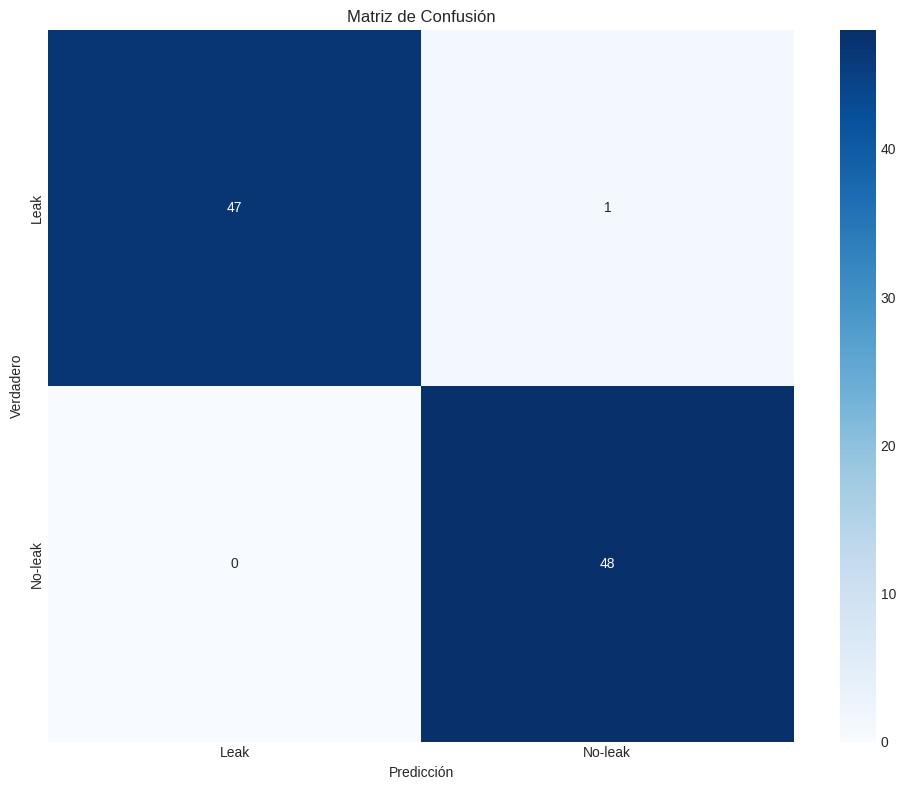


Reporte de clasificación:
              precision    recall  f1-score   support

        Leak       1.00      0.98      0.99        48
     No-leak       0.98      1.00      0.99        48

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



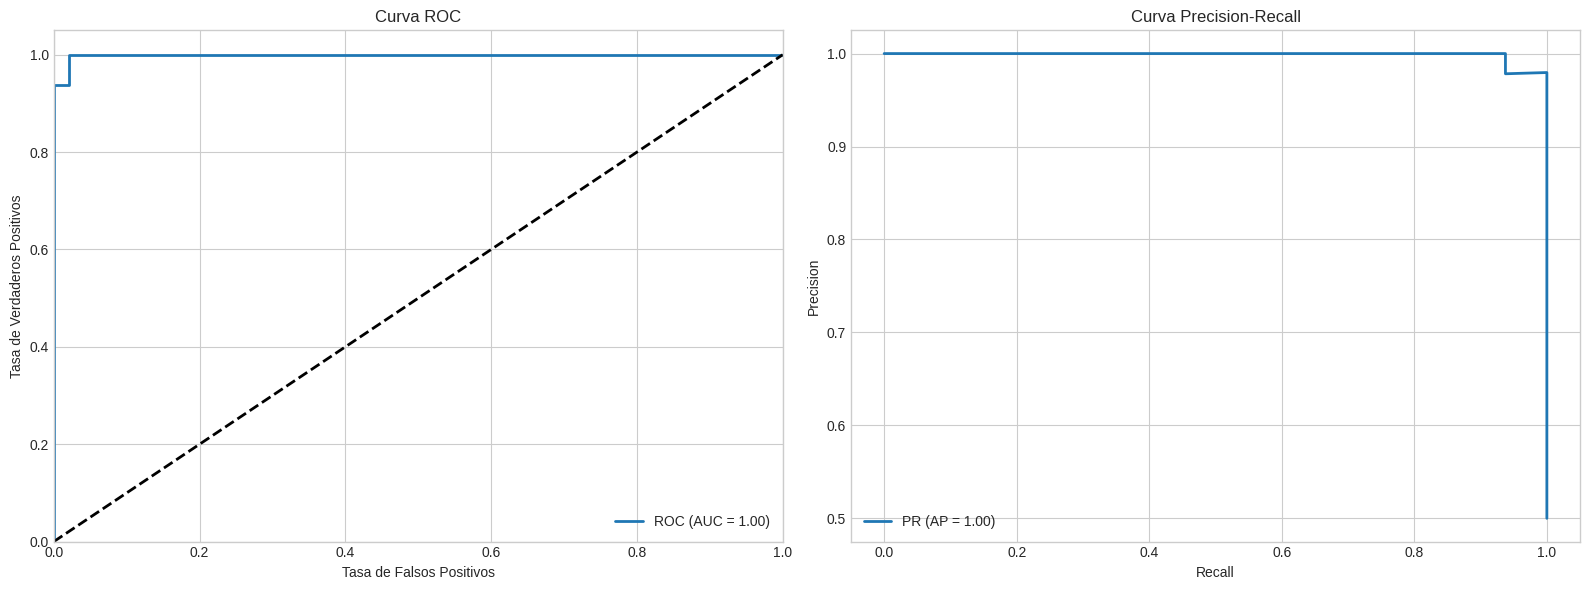


Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [ ]:
#Data Augmentation y otras mejoras
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ----------------------------------------------------------------------------------
# CLASE DEL MODELO (LIGERAMENTE MODIFICADA PARA PERMITIR UNFREEZING)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True, unfreeze_blocks=False):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        self.vit = vit_base_patch16_224(pretrained=True)

        # Ajustar la capa de embedding de parches para el tamaño de entrada
        self.vit.patch_embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=(16, 16), stride=(16, 16), padding='valid')

        # Recalcular el número de patches para el embedding de posición
        num_patches_h = (input_shape[1] - self.vit.patch_embed.kernel_size[0]) // self.vit.patch_embed.stride[0] + 1
        num_patches_w = (input_shape[2] - self.vit.patch_embed.kernel_size[1]) // self.vit.patch_embed.stride[1] + 1
        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches_h * num_patches_w + 1, self.vit.pos_embed.shape[2])
        )

        # Ajustar la capa de salida (head)
        if self.is_binary:
            self.vit.head = nn.Linear(self.vit.head.in_features, 1)
        else:
            self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

        # Congelar todas las capas por defecto
        for param in self.vit.parameters():
            param.requires_grad = False

        # Descongelar las capas para fine-tuning
        self.vit.patch_embed.requires_grad_(True)
        self.vit.pos_embed.requires_grad_(True)
        self.vit.head.requires_grad_(True)

        if unfreeze_blocks:
            # Descongela los últimos 4 bloques del Transformer para fine-tuning
            for i in range(8, 12):
                for param in self.vit.blocks[i].parameters():
                    param.requires_grad = True

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed[:, :x.size(1)]
        x = self.vit.norm(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        x = self.vit.head(x[:, 0])

        if self.is_binary:
            return torch.sigmoid(x)
        else:
            return x

# ----------------------------------------------------------------------------------
# CONFIGURACIÓN Y DATOS (ASUME QUE ESTÁN DEFINIDOS PREVIAMENTE)
# ----------------------------------------------------------------------------------
# Estas variables deben estar definidas antes de ejecutar este bloque:
# x_train_final, y_train_final, x_val, y_val, x_test, y_test
# classification_mode = 'binary'
# num_classes = 2 # o 5 si es multiclase

# Parámetros del entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
BATCH_SIZE = 32
epochs = 250

early_stop_patience = 20
model_save_path = f'/content/drive/MyDrive/STFT/Branched/vit_stft_{classification_mode}_db38_lv4_optimized.pt'
UNFREEZE_BLOCKS = True # Cambia a True para fine-tuning más profundo

# Preparar DataLoaders
train_dataset = TensorDataset(x_train_final, y_train_final)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

# Instanciar modelo, criterio y optimizador
is_binary = (classification_mode == 'binary')
num_classes_final = 2 if is_binary else num_classes
model = LogPSViT(input_shape=(3, 257, 101), num_classes=num_classes_final, is_binary=is_binary, unfreeze_blocks=UNFREEZE_BLOCKS)
model.to(device)

# Calcular el peso para el balanceo de clases si es un problema binario
if is_binary:
    positive_weight = len(y_train_final) / (2 * y_train_final.sum())
    criterion = nn.BCELoss(weight=torch.tensor([positive_weight]).to(device))
else:
    criterion = nn.CrossEntropyLoss()

# Hiperparámetros de entrenamiento
learning_rate = 1e-4 if not UNFREEZE_BLOCKS else 5e-6 # Menor LR para fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.005) # Aumento de weight_decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=8, min_lr=1e-7)

# Transformaciones para aumento de datos en el conjunto de entrenamiento
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformación de normalización para validación y prueba
val_test_transforms = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Historial de entrenamiento
history = {
    'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []
}
best_val_loss = float('inf')
epochs_no_improve = 0

# ----------------------------------------------------------------------------------
# BUCLE DE ENTRENAMIENTO Y VALIDACIÓN
# ----------------------------------------------------------------------------------
print("\nComenzando el entrenamiento del modelo Vision Transformer optimizado...")

for epoch in range(epochs):
    start_time = time.time()

    # Bucle de entrenamiento
    model.train()
    train_loss = 0.0
    train_correct_preds = 0
    train_total_samples = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = train_transforms(inputs) # Aplicar aumento de datos

        if is_binary: labels_for_loss = labels.float().unsqueeze(1)
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

        if is_binary: preds = (outputs > 0.5).squeeze()
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Bucle de validación
    model.eval()
    val_loss = 0.0
    val_correct_preds = 0
    val_total_samples = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = val_test_transforms(inputs) # Normalización sin aumento de datos

            if is_binary: labels_for_loss = labels.float().unsqueeze(1)
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if is_binary: preds = (outputs > 0.5).squeeze()
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f} | "
          f"Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
# EVALUACIÓN Y VISUALIZACIÓN DEL RENDIMIENTO (SIN CAMBIOS)
# ----------------------------------------------------------------------------------
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Cargar el mejor modelo
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Obtener predicciones y etiquetas
y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs = inputs.to(device)
        inputs = val_test_transforms(inputs)
        outputs = model(inputs)
        y_pred_prob.extend(outputs.cpu().numpy())
        y_test_true.extend(labels.cpu().numpy())

y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

if is_binary:
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_pred_prob_positive = y_pred_prob.flatten()
    y_test_flat = y_test_true.flatten()
    class_names = ['Leak', 'No-leak']
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    class_names = ['Circumferential Crack', 'Gasket Leak', 'Longitudinal Crack', 'No-leak', 'Orifice Leak']

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
report = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_test_true, y_pred, target_names=class_names))

# Gráficos de rendimiento
if is_binary:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob_positive)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_prob_positive)
    ap = average_precision_score(y_test_flat, y_pred_prob_positive)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=num_classes).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score = y_pred_prob[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

##NUEVO CODIGO CON REPORTE ACTUALIZADO MAS DETALLADO


Usando dispositivo: cuda

Comenzando el entrenamiento del modelo Vision Transformer optimizado...


Epoch 1 (Val): 100%|██████████| 2/2 [00:00<00:00,  5.29it/s]


Epoch 1/250: Train Loss: 0.6671, Train Acc: 0.5868 | Val Loss: 0.6684, Val Acc: 0.7188 | LR: 0.0000050 | Tiempo: 4.28s
Mejor modelo guardado en /content/drive/MyDrive/STFT modelo preentrenado/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.6684)


Epoch 2 (Val): 100%|██████████| 2/2 [00:00<00:00,  5.17it/s]


Epoch 2/250: Train Loss: 0.6391, Train Acc: 0.6840 | Val Loss: 0.6449, Val Acc: 0.8125 | LR: 0.0000050 | Tiempo: 4.30s
Mejor modelo guardado en /content/drive/MyDrive/STFT modelo preentrenado/Branched/vit_stft_binary_db38_lv4_optimized.pt (Val Loss: 0.6449)


...

Epoch 69/250: Train Loss: 0.0698, Train Acc: 0.9792 | Val Loss: 0.0411, Val Acc: 1.0000 | LR: 0.0000002 | Tiempo: 4.39s


Epoch 70 (Val): 100%|██████████| 2/2 [00:00<00:00,  5.21it/s]


Epoch 70/250: Train Loss: 0.1362, Train Acc: 0.9340 | Val Loss: 0.0471, Val Acc: 1.0000 | LR: 0.0000002 | Tiempo: 4.33s
Early stopping activado después de 20 épocas sin mejora.

Entrenamiento finalizado.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test: 100%|██████████| 3/3 [00:00<00:00,  5.45it/s]



Generando matriz de confusión...


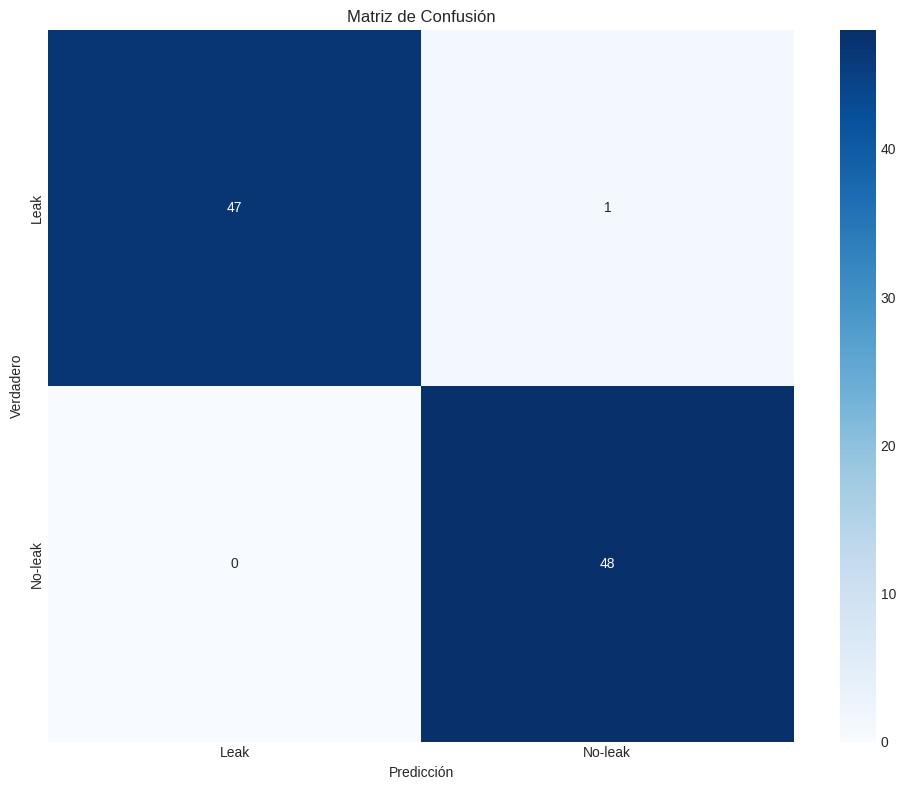


Reporte de clasificación por clase:


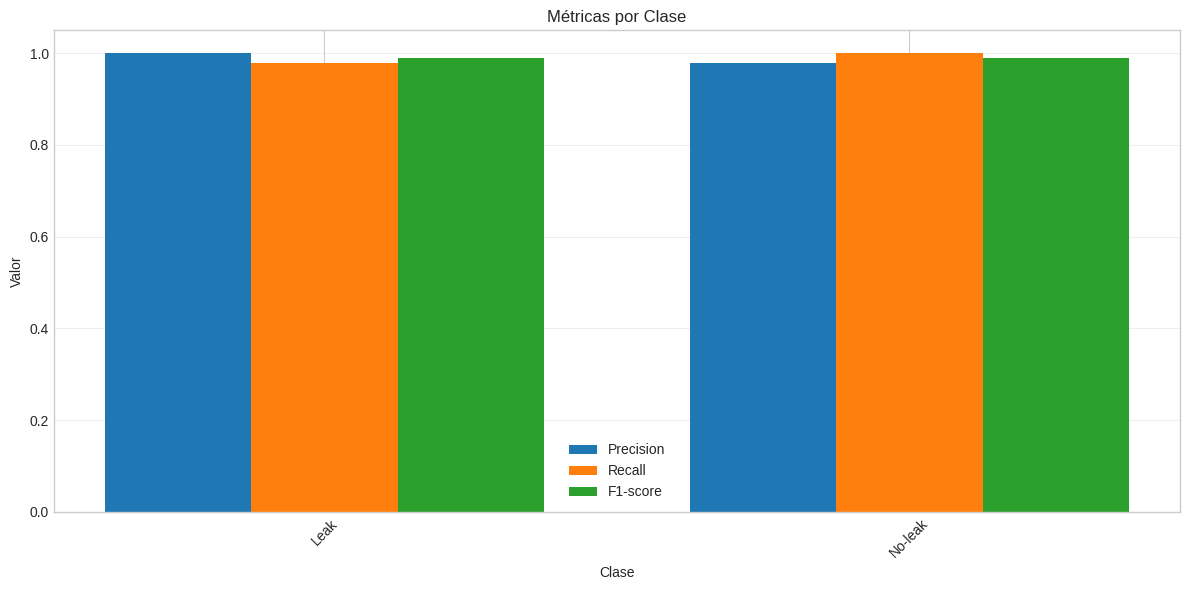

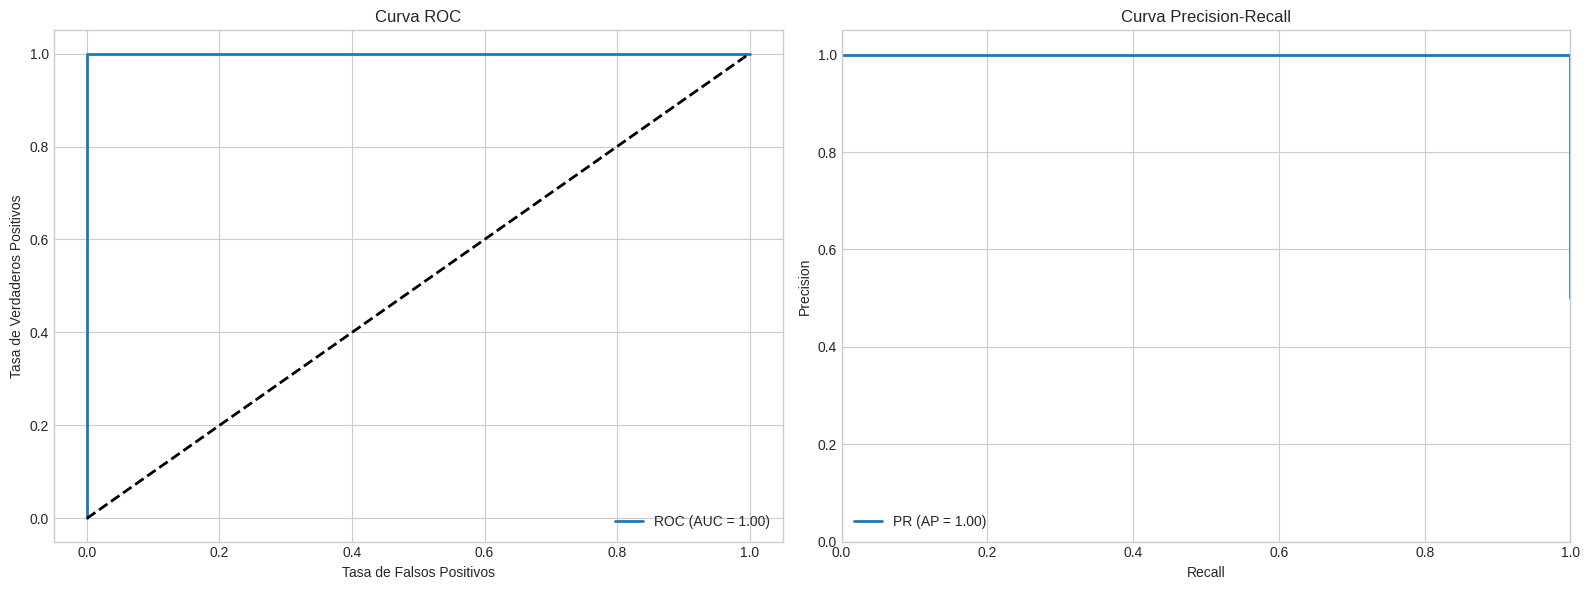


==== INFORME DETALLADO DE EVALUACIÓN EN TEST ====

- Exactitud: 0.9896

Reporte de clasificación por clase:
- Leak: Precisión=1.0000, Recall=0.9792, F1=0.9895
- No-leak: Precisión=0.9796, Recall=1.0000, F1=0.9897

Promedios ponderados:
- Precisión: 0.9898
- Recall: 0.9896
- F1-Score: 0.9896

Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [14]:
#Data Augmentation y otras mejoras
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ----------------------------------------------------------------------------------
# CLASE DEL MODELO (LIGERAMENTE MODIFICADA PARA PERMITIR UNFREEZING)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True, unfreeze_blocks=False):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        self.vit = vit_base_patch16_224(pretrained=True)

        # Ajustar la capa de embedding de parches para el tamaño de entrada
        self.vit.patch_embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=(16, 16), stride=(16, 16), padding='valid')

        # Recalcular el número de patches para el embedding de posición
        num_patches_h = (input_shape[1] - self.vit.patch_embed.kernel_size[0]) // self.vit.patch_embed.stride[0] + 1
        num_patches_w = (input_shape[2] - self.vit.patch_embed.kernel_size[1]) // self.vit.patch_embed.stride[1] + 1
        self.vit.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches_h * num_patches_w + 1, self.vit.pos_embed.shape[2])
        )

        # Ajustar la capa de salida (head)
        if self.is_binary:
            self.vit.head = nn.Linear(self.vit.head.in_features, 1)
        else:
            self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

        # Congelar todas las capas por defecto
        for param in self.vit.parameters():
            param.requires_grad = False

        # Descongelar las capas para fine-tuning
        self.vit.patch_embed.requires_grad_(True)
        self.vit.pos_embed.requires_grad_(True)
        self.vit.head.requires_grad_(True)

        if unfreeze_blocks:
            # Descongela los últimos 4 bloques del Transformer para fine-tuning
            for i in range(8, 12):
                for param in self.vit.blocks[i].parameters():
                    param.requires_grad = True

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed[:, :x.size(1)]
        x = self.vit.norm(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        x = self.vit.head(x[:, 0])

        if self.is_binary:
            return torch.sigmoid(x)
        else:
            return x

# ----------------------------------------------------------------------------------
# CONFIGURACIÓN Y DATOS (ASUME QUE ESTÁN DEFINIDOS PREVIAMENTE)
# ----------------------------------------------------------------------------------
# Estas variables deben estar definidas antes de ejecutar este bloque:
# x_train_final, y_train_final, x_val, y_val, x_test, y_test
# classification_mode = 'binary'
# num_classes = 2 # o 5 si es multiclase

# Parámetros del entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
BATCH_SIZE = 32
epochs = 250

early_stop_patience = 20
model_save_path = f'/content/drive/MyDrive/STFT modelo preentrenado/Branched/vit_stft_{classification_mode}_db38_lv4_optimized.pt'
UNFREEZE_BLOCKS = True # Cambia a True para fine-tuning más profundo

# Preparar DataLoaders
train_dataset = TensorDataset(x_train_final, y_train_final)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

# Instanciar modelo, criterio y optimizador
is_binary = (classification_mode == 'binary')
num_classes_final = 2 if is_binary else num_classes
model = LogPSViT(input_shape=(3, 257, 101), num_classes=num_classes_final, is_binary=is_binary, unfreeze_blocks=UNFREEZE_BLOCKS)
model.to(device)

# Calcular el peso para el balanceo de clases si es un problema binario
if is_binary:
    positive_weight = len(y_train_final) / (2 * y_train_final.sum())
    criterion = nn.BCELoss(weight=torch.tensor([positive_weight]).to(device))
else:
    criterion = nn.CrossEntropyLoss()

# Hiperparámetros de entrenamiento
learning_rate = 1e-4 if not UNFREEZE_BLOCKS else 5e-6 # Menor LR para fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.005) # Aumento de weight_decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=8, min_lr=1e-7)

# Transformaciones para aumento de datos en el conjunto de entrenamiento
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformación de normalización para validación y prueba
val_test_transforms = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Historial de entrenamiento
history = {
    'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []
}
best_val_loss = float('inf')
epochs_no_improve = 0

# ----------------------------------------------------------------------------------
# BUCLE DE ENTRENAMIENTO Y VALIDACIÓN
# ----------------------------------------------------------------------------------
print("\nComenzando el entrenamiento del modelo Vision Transformer optimizado...")

for epoch in range(epochs):
    start_time = time.time()

    # Bucle de entrenamiento
    model.train()
    train_loss = 0.0
    train_correct_preds = 0
    train_total_samples = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = train_transforms(inputs) # Aplicar aumento de datos

        if is_binary: labels_for_loss = labels.float().unsqueeze(1)
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

        if is_binary: preds = (outputs > 0.5).squeeze()
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Bucle de validación
    model.eval()
    val_loss = 0.0
    val_correct_preds = 0
    val_total_samples = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = val_test_transforms(inputs) # Normalización sin aumento de datos

            if is_binary: labels_for_loss = labels.float().unsqueeze(1)
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if is_binary: preds = (outputs > 0.5).squeeze()
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f} | "
          f"Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
# EVALUACIÓN Y VISUALIZACIÓN DEL RENDIMIENTO (SIN CAMBIOS)
# ----------------------------------------------------------------------------------
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Cargar el mejor modelo
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Obtener predicciones y etiquetas
y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs = inputs.to(device)
        inputs = val_test_transforms(inputs)
        outputs = model(inputs)
        y_pred_prob.extend(outputs.cpu().numpy())
        y_test_true.extend(labels.cpu().numpy())

y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

if is_binary:
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_pred_prob_positive = y_pred_prob.flatten()
    y_test_flat = y_test_true.flatten()
    class_names = ['Leak', 'No-leak']
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    # **NOTA**: Asumimos que `num_classes` y el orden de clases es correcto para el reporte.
    # En el código original: class_names = ['Circumferential Crack', 'Gasket Leak', 'Longitudinal Crack', 'No-leak', 'Orifice Leak']
    # Usaremos el orden de clases que definiste para el código original para la exactitud.
    if 'num_classes' in locals() and num_classes == 5:
        class_names = ['Circumferential Crack', 'Gasket Leak', 'Longitudinal Crack', 'No-leak', 'Orifice Leak']
    else:
        class_names = [f'Clase {i}' for i in range(num_classes_final)]

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Reporte de clasificación (COMENTADO según solicitud del usuario)
# print("\nReporte de clasificación:")
# report = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)
# print(classification_report(y_test_true, y_pred, target_names=class_names))

# ----------------------------------------------------------------------------------
# NUEVO REPORTE DE CLASIFICACIÓN Y VISUALIZACIÓN DE MÉTRICAS (SOLICITADO)
# ----------------------------------------------------------------------------------
# La variable 'y_pred_prob' ya fue calculada y contiene las probabilidades de predicción.
# La variable 'y_test_true' ya fue calculada y contiene las etiquetas verdaderas.
# La variable 'y_pred' ya fue calculada y contiene las predicciones de clase.
# La variable 'class_names' ya fue definida.

vit_test_acc = (y_pred == y_test_true).mean()
report = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)
total_samples_test = len(y_test_true)
# La lógica de tiempo de inferencia no está disponible aquí, la omitimos.

# 1. Gráficos de Métricas por clase (Precision, Recall, F1)
print("\nReporte de clasificación por clase:")
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    # Aseguramos que se usan solo las clases existentes en el reporte
    values = [report[cls][metric] for cls in class_names]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Curva ROC (incluida en el código original, pero la rehacemos aquí para incluir el informe detallado)
if is_binary:
    y_score = y_pred_prob_positive
else:
    y_score = y_pred_prob # Para multiclase

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1) # Usaremos el primer subplot para ROC y el segundo para PR

if is_binary: # ROC binaria
    fpr, tpr, _ = roc_curve(y_test_flat, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria (segundo subplot, como en el código original)
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_score)
    ap = average_precision_score(y_test_flat, y_score)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

else: # Multiclase
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=num_classes_final).float().numpy()

    # ROC multiclase
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score_cls = y_score[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score_cls)
        ap = average_precision_score(y_true_binary, y_score_cls)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()


# 3. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN EN TEST ====\n")
print(f"- Exactitud: {vit_test_acc:.4f}")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    cls_metrics = report[cls]
    print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
          f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

# Métricas globales (promedio ponderado)
if 'weighted avg' in report:
    weighted_avg = report['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# ----------------------------------------------------------------------------------
# FIN DEL NUEVO REPORTE
# ----------------------------------------------------------------------------------


print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")